In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

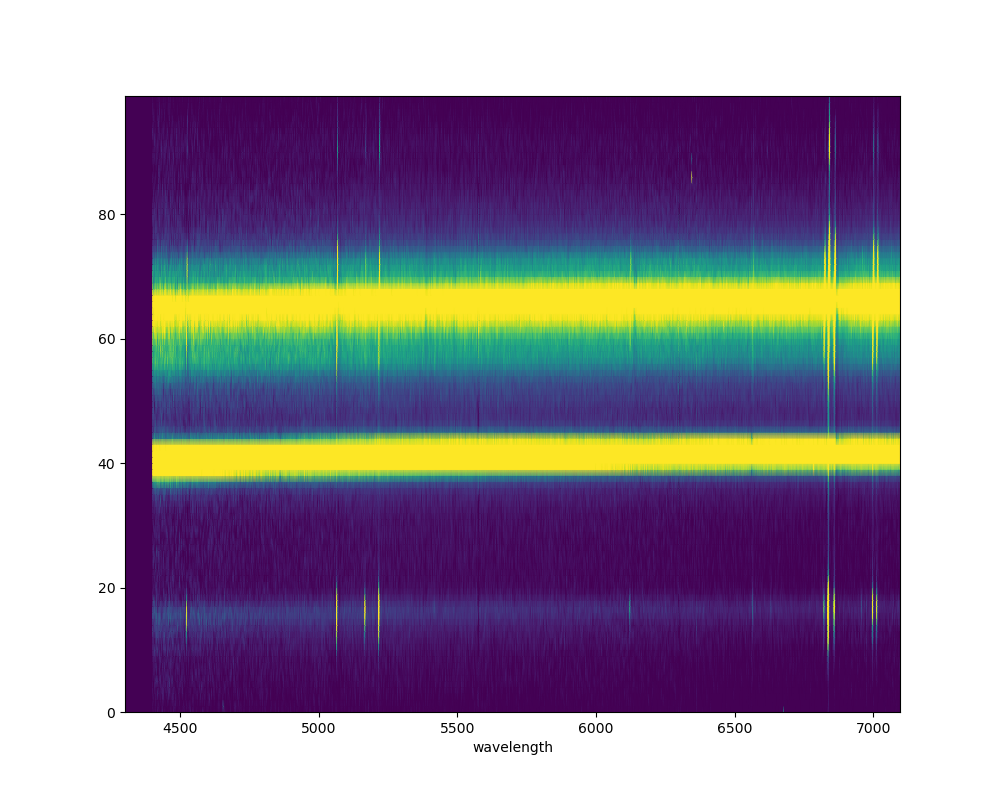

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35
n_component = 6
print(sigmas)

[1.00391516 1.0803587  1.00353273 1.00194585 1.0715137 ]


In [7]:
l_HA

6842.78069

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

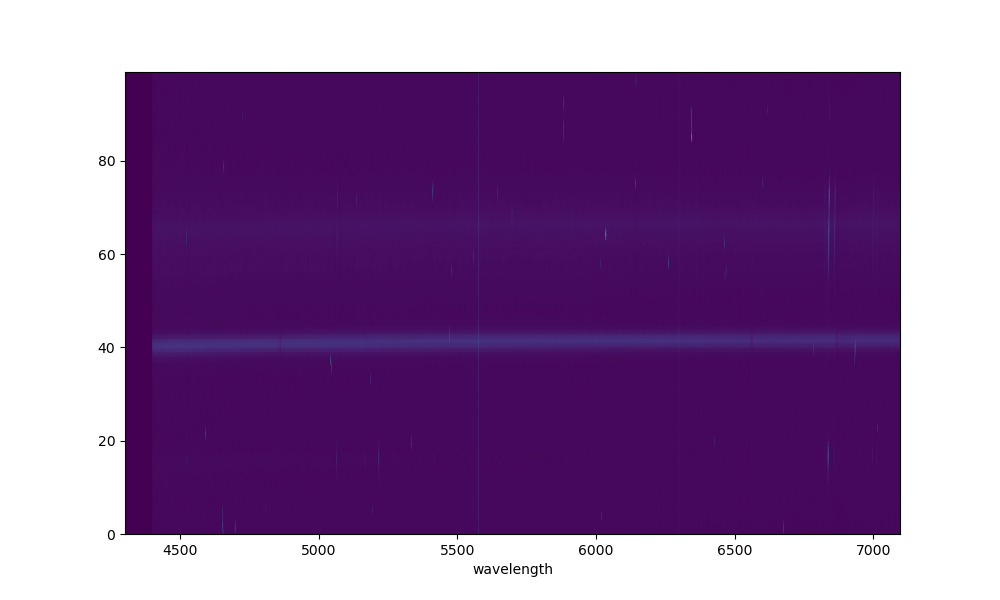

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[49:149, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

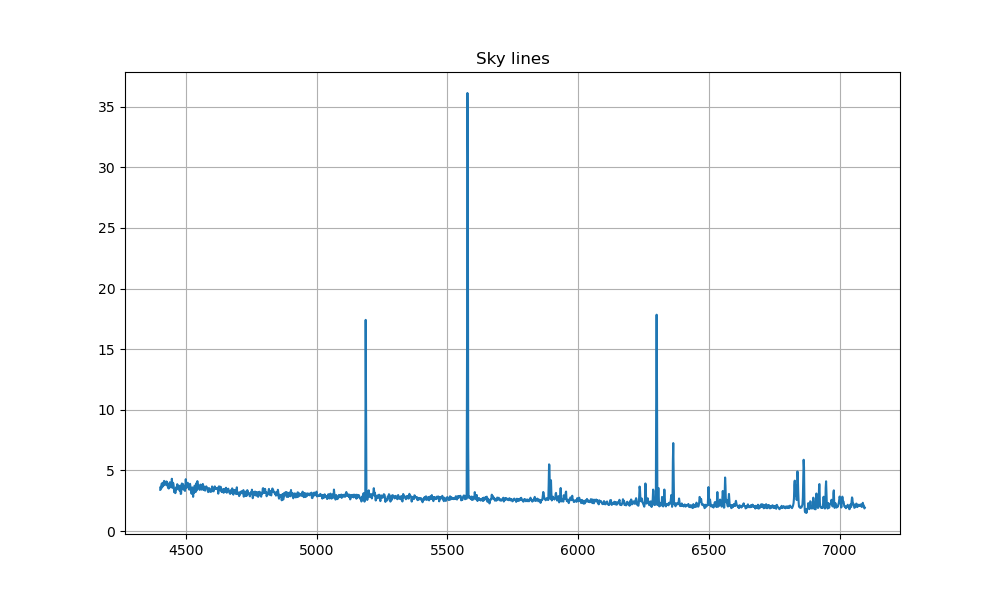

In [9]:
mask_sky = (y > 25)*(y < 35)
mask_wv = wv > 4400
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

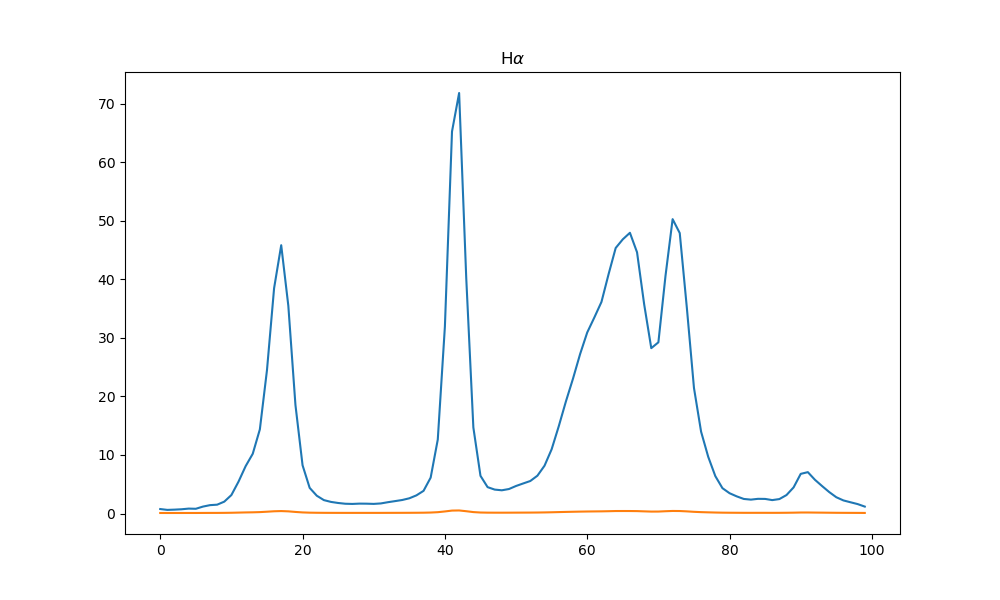

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 85)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 85)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 51072.74211257182
differential_evolution step 2: f(x)= 29514.523388372254
differential_evolution step 3: f(x)= 29514.523388372254
differential_evolution step 4: f(x)= 29514.523388372254
differential_evolution step 5: f(x)= 29514.523388372254
differential_evolution step 6: f(x)= 25000.027327249427
differential_evolution step 7: f(x)= 18467.078248398408
differential_evolution step 8: f(x)= 13540.540214617758
differential_evolution step 9: f(x)= 13540.540214617758
differential_evolution step 10: f(x)= 13540.540214617758
differential_evolution step 11: f(x)= 13540.540214617758
differential_evolution step 12: f(x)= 12723.430163204284
differential_evolution step 13: f(x)= 12723.430163204284
differential_evolution step 14: f(x)= 12394.905372543926
differential_evolution step 15: f(x)= 12394.905372543926
differential_evolution step 16: f(x)= 12394.905372543926
differential_evolution step 17: f(x)= 12394.905372543926
differential_evolution step 18: f(x)= 109

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17704\68776662.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=2.1155, r_e=8.3744, n=2.4176, x_0=16.7774
Sérsic 2: I_e=2.7449, r_e=4.8895, n=3.0754, x_0=41.6152
Sérsic 3: I_e=8.1185, r_e=6.2744, n=0.7696, x_0=60.5988
Sérsic 4: I_e=7.9954, r_e=4.7782, n=1.0563, x_0=65.7019
Sérsic 5: I_e=6.1515, r_e=4.7517, n=1.5019, x_0=72.5517
Sérsic 6: I_e=1.0943, r_e=8.1261, n=1.1679, x_0=91.0623
Chi quadro minimo: 92.17477243725068
False


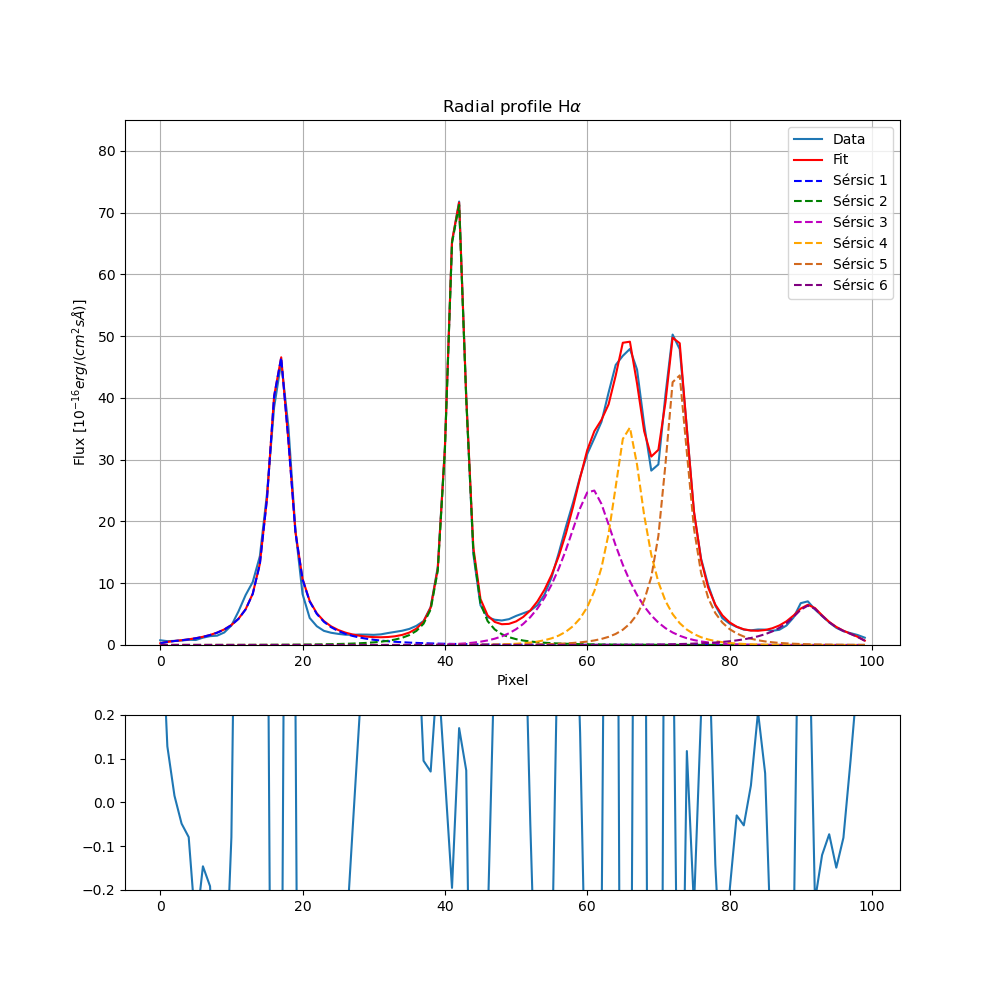

In [13]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, 
                                           p0=result.x, sigma = radial_profile_error_HA, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.0491, r_e=8.2235, n=2.4864, x_0=16.6898
Sérsic 2: I_e=2.7264, r_e=4.9769, n=3.0521, x_0=41.6152
Sérsic 3: I_e=8.1193, r_e=6.3395, n=0.7675, x_0=60.5951
Sérsic 4: I_e=7.9941, r_e=4.7638, n=1.0552, x_0=65.6874
Sérsic 5: I_e=6.1305, r_e=4.7127, n=1.5057, x_0=72.5644
Sérsic 6: I_e=1.0733, r_e=8.1056, n=1.1915, x_0=91.1046
[7.67326831e-01 1.97097710e+00 3.32148279e-01 5.06933529e-02
 3.01461855e+00 3.02547149e+00 2.25378243e+00 2.65748122e-04
 4.33701922e+00 7.63023968e-01 1.24825035e-01 7.02639314e-01
 1.32564746e+01 9.22575074e+00 1.11797922e+00 2.35491306e-01
 2.26519836e+00 2.38692555e+00 2.86228320e-01 1.35726906e-01
 9.88348800e-01 6.11345996e+00 6.11692511e-01 2.72177122e-01]
27.247920267282236


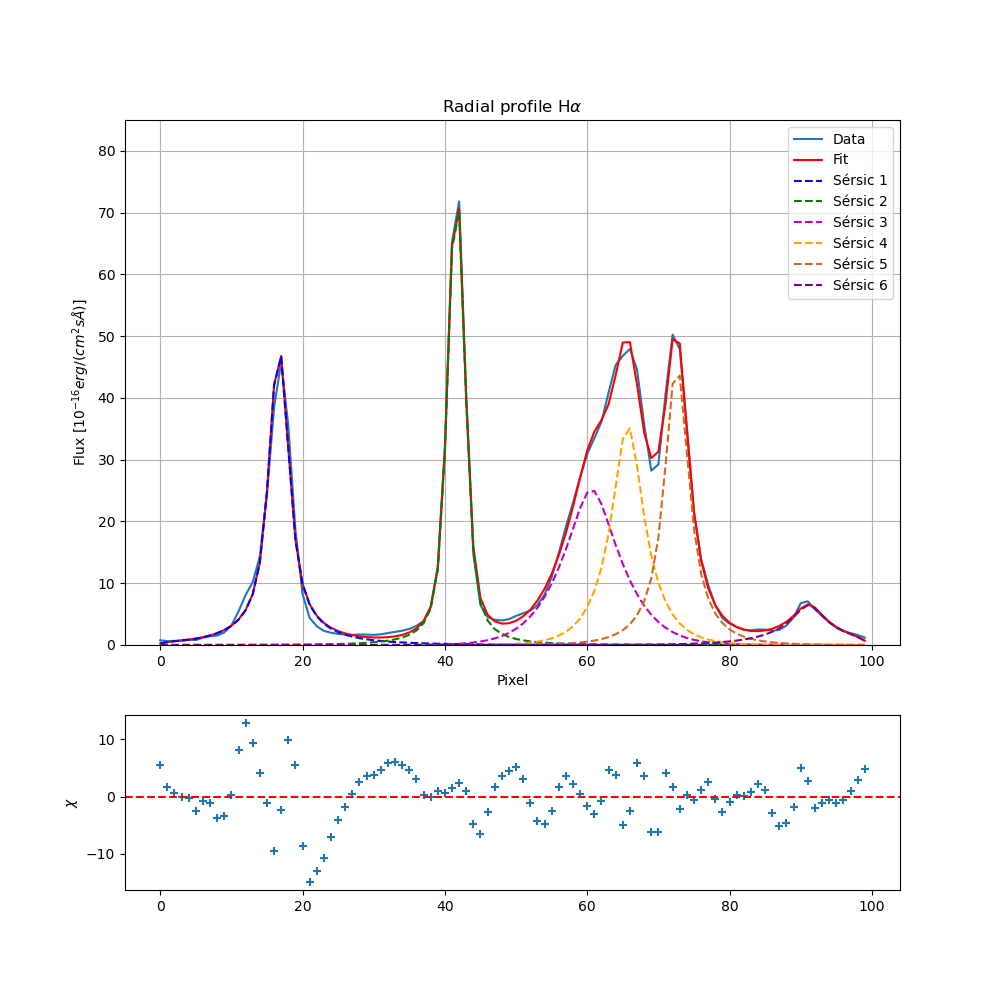

In [15]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [59]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.15, x_0_HA[0]+1.15),   # x_0: circa la posizione di Halpha

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.15, x_0_HA[1]+1.15),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.15, x_0_HA[2]+1.15),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.15, x_0_HA[3]+1.15),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.15, x_0_HA[4]+1.15),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.15, x_0_HA[4]+1.15),
    
    (0, 10),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.15, x_0_HA[5]+1.15)
]

In [60]:
bounds

[(0, 10),
 (0, 50),
 (0.1, 10),
 (15.539800000000001, 17.8398),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (40.4652, 42.7652),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (59.445100000000004, 61.7451),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (64.53739999999999, 66.8374),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (71.4144, 73.71440000000001),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (71.4144, 73.71440000000001),
 (0, 10),
 (0, 50),
 (0.1, 10),
 (89.9546, 92.25460000000001)]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

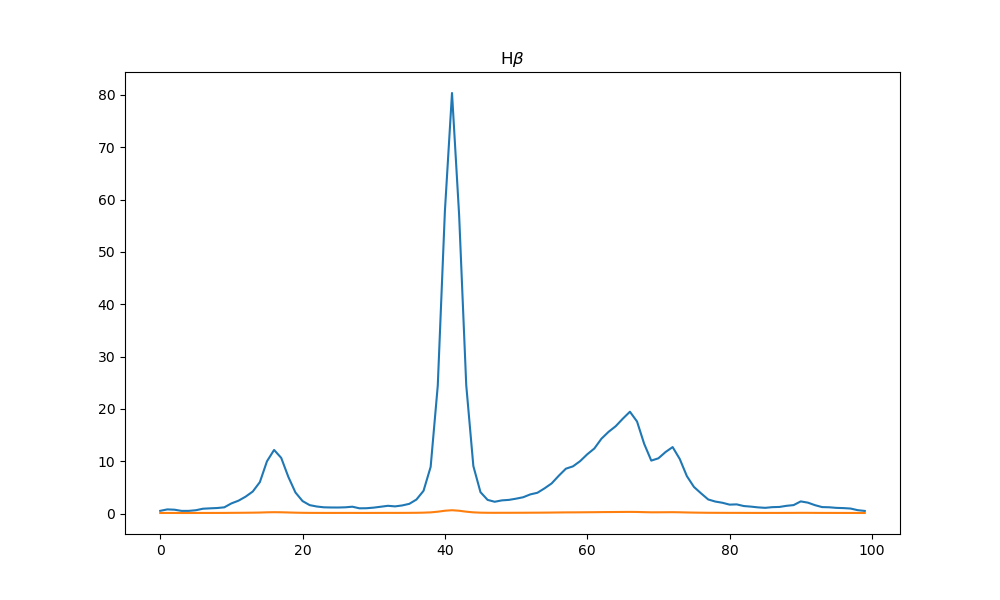

In [61]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [64]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds = bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 118005.02522971814
differential_evolution step 2: f(x)= 118005.02522971814
differential_evolution step 3: f(x)= 9143.455646343122
differential_evolution step 4: f(x)= 8564.056440110306
differential_evolution step 5: f(x)= 8564.056440110306
differential_evolution step 6: f(x)= 8564.056440110306
differential_evolution step 7: f(x)= 3210.337587916651
differential_evolution step 8: f(x)= 2276.127777885882
differential_evolution step 9: f(x)= 2276.127777885882
differential_evolution step 10: f(x)= 2276.127777885882
differential_evolution step 11: f(x)= 2276.127777885882
differential_evolution step 12: f(x)= 2276.127777885882
differential_evolution step 13: f(x)= 2276.127777885882
differential_evolution step 14: f(x)= 2133.7369938520183
differential_evolution step 15: f(x)= 2133.7369938520183
differential_evolution step 16: f(x)= 2133.7369938520183
differential_evolution step 17: f(x)= 2133.7369938520183
differential_evolution step 18: f(x)= 1127.26625140

KeyboardInterrupt: 

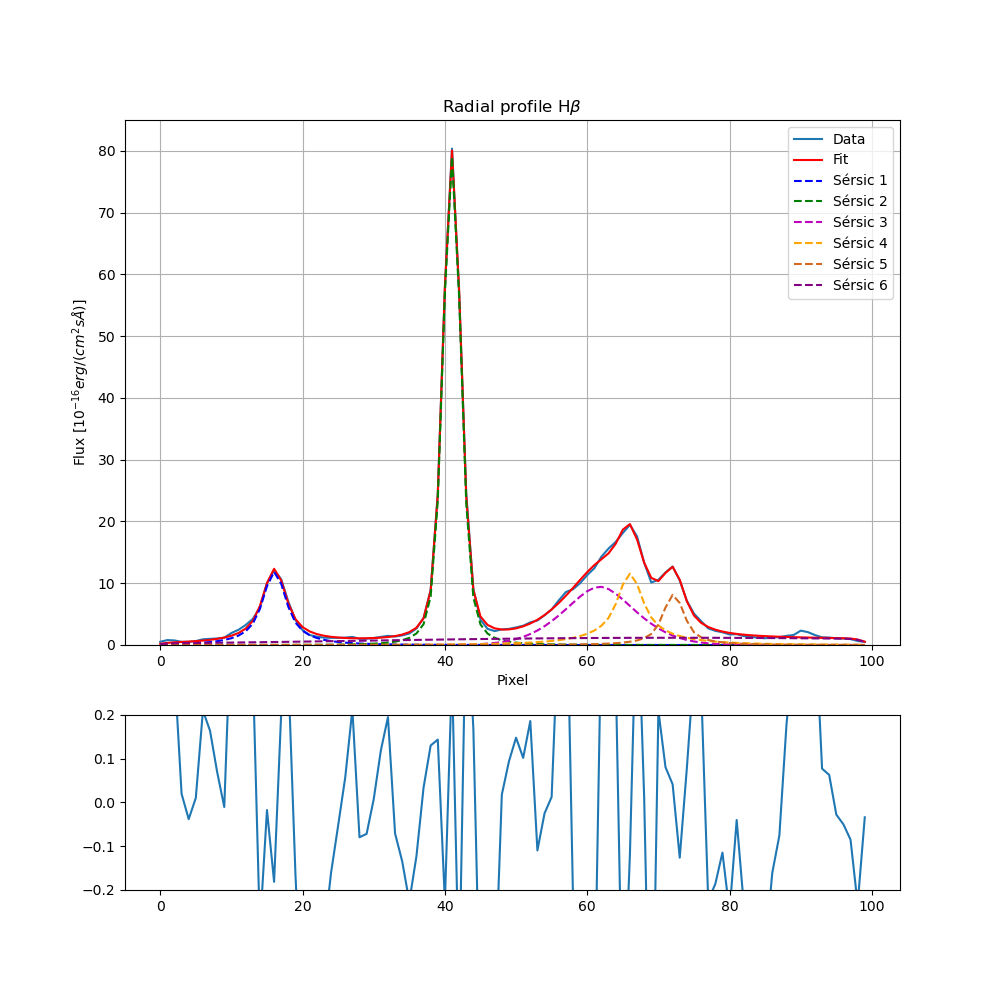

In [63]:
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [53]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.1189, r_e=5.3924, n=1.8443, x_0=15.9877
Sérsic 2: I_e=9.7569, r_e=1.9534, n=2.3586, x_0=40.9782
Sérsic 3: I_e=4.3739, r_e=6.7694, n=0.6375, x_0=61.7451
Sérsic 4: I_e=4.5400, r_e=2.0662, n=0.7169, x_0=65.9671
Sérsic 5: I_e=0.7445, r_e=49.9993, n=0.4766, x_0=71.4290
Sérsic 6: I_e=1.7346, r_e=3.4184, n=1.3259, x_0=72.0542
[ 0.73242796  2.60283514  0.50610085  0.060872    3.50730819  0.37435574
  0.37179587  0.01482311  2.55012247  1.01421259  0.15468776  3.49545658
  4.17657462  2.63488956  0.76224688  0.29279592  0.21774009 11.60172474
  0.24084114  8.90555436  1.41548935  2.56837954  0.63806802  0.210588
  0.          0.          0.          0.        ]
4.770042849137287


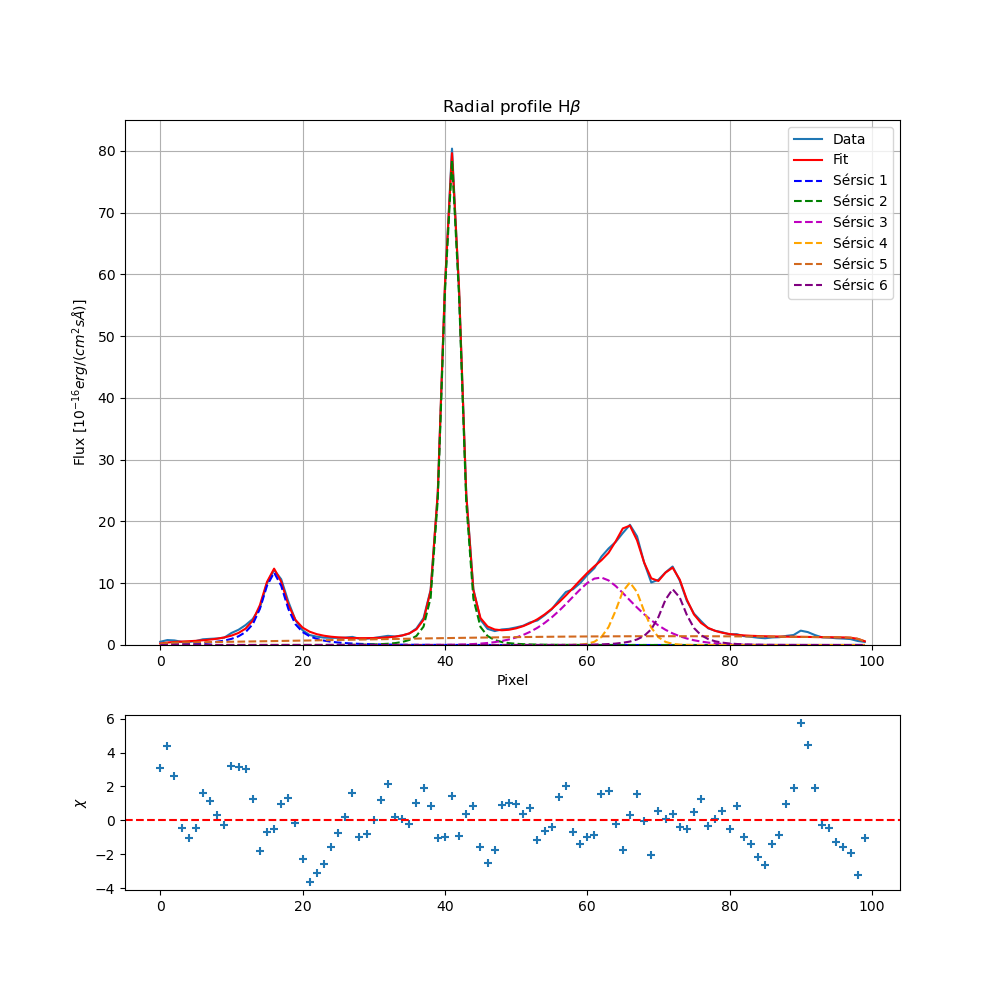

In [54]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

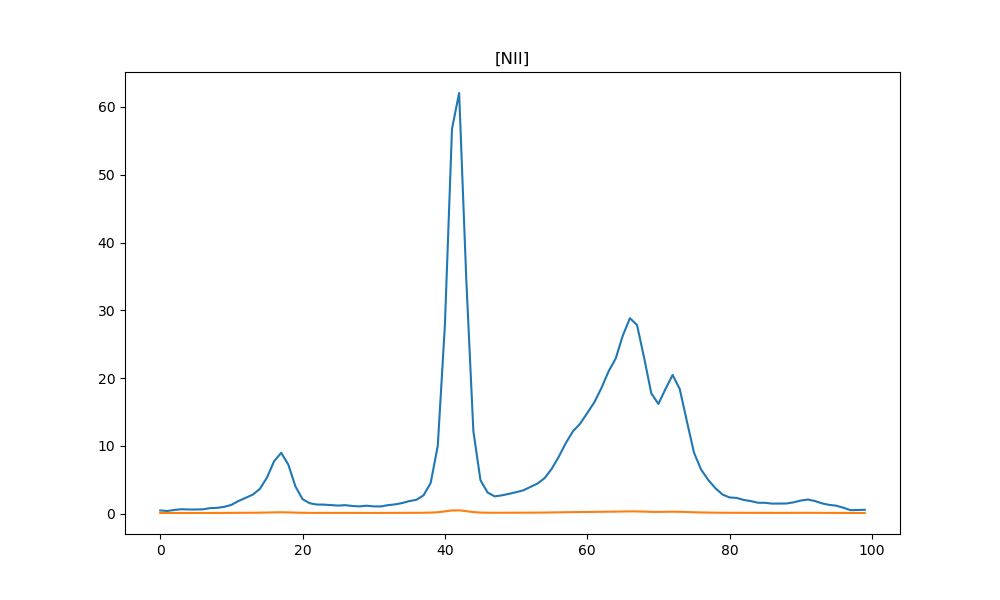

In [55]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [56]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 141115.18473755335
differential_evolution step 2: f(x)= 141115.18473755335
differential_evolution step 3: f(x)= 21759.27801885421
differential_evolution step 4: f(x)= 21759.27801885421
differential_evolution step 5: f(x)= 21759.27801885421
differential_evolution step 6: f(x)= 21747.48669150554
differential_evolution step 7: f(x)= 21747.48669150554
differential_evolution step 8: f(x)= 21747.48669150554
differential_evolution step 9: f(x)= 18557.732885892823
differential_evolution step 10: f(x)= 8116.1643904676985
differential_evolution step 11: f(x)= 5527.876989925824
differential_evolution step 12: f(x)= 5527.876989925824
differential_evolution step 13: f(x)= 5527.876989925824
differential_evolution step 14: f(x)= 4187.911163401185
differential_evolution step 15: f(x)= 4187.911163401185
differential_evolution step 16: f(x)= 4187.911163401185
differential_evolution step 17: f(x)= 2190.7233246756778
differential_evolution step 18: f(x)= 2190.723324675

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17704\68776662.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.8462, r_e=5.1719, n=1.7561, x_0=16.7110
Sérsic 2: I_e=6.1138, r_e=2.3238, n=2.4959, x_0=41.6043
Sérsic 3: I_e=5.2313, r_e=5.6425, n=0.4943, x_0=61.7278
Sérsic 4: I_e=1.7669, r_e=12.0295, n=1.6620, x_0=66.3206
Sérsic 5: I_e=0.8427, r_e=49.7320, n=0.2102, x_0=72.8258
Sérsic 6: I_e=3.4808, r_e=2.6768, n=1.1062, x_0=72.4418
Chi quadro minimo: 11.149206400530586
False


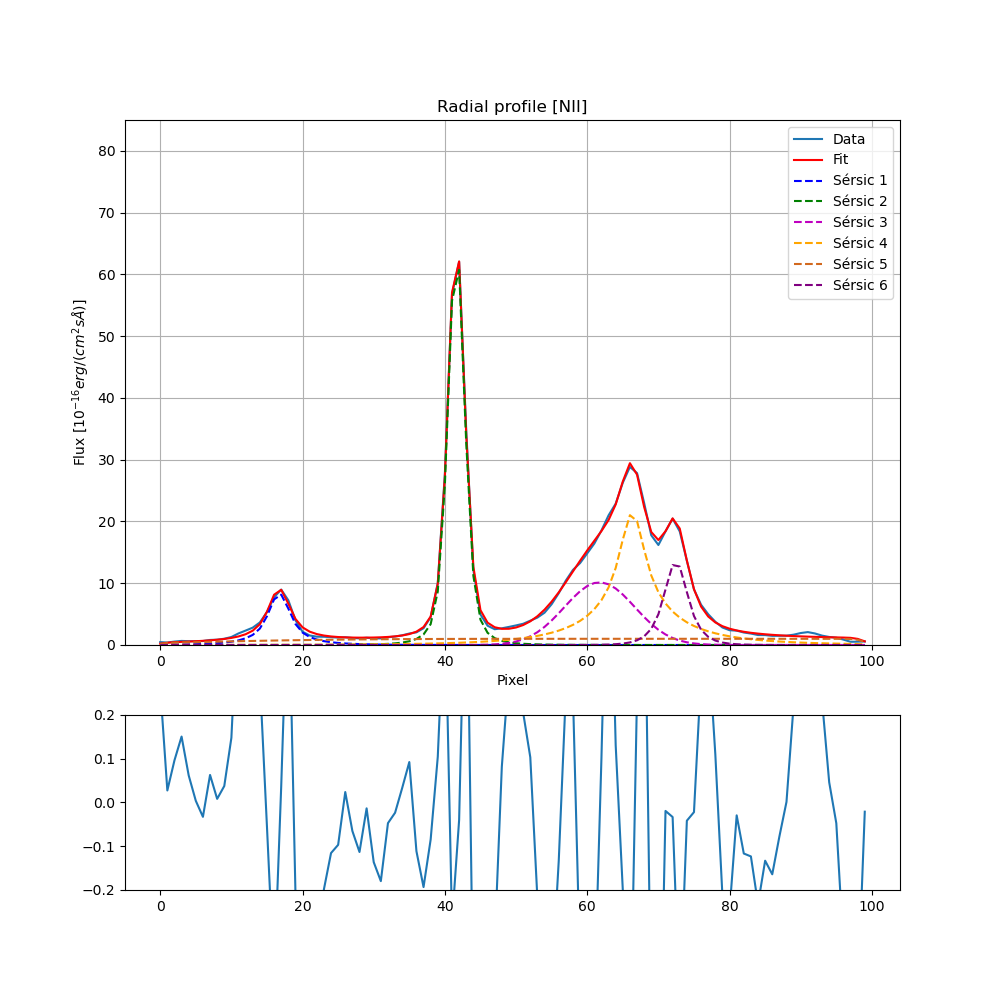

In [57]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [58]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

In [ ]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [ ]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

In [ ]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [ ]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = radial_profile_error_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [ ]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

In [ ]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

In [ ]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[5], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2, radial_profile_error_continuum_2,
                                                                          sigmas[5], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

In [ ]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          radial_profile_error_continuum_3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [ ]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
